<a href="https://colab.research.google.com/github/CeZa18/ITAI-1371-ML-Labs/blob/main/L06_CesarZaldivar_ITAI1371.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 06 Lab - Regression and Classification Models
**Objective:** To understand the difference between regression and classification and to build your first linear models for both tasks. **In this lab, you will write the code to train and evaluate the models.**

## Part 1: Regression vs. Classification
This is the most fundamental distinction between types of supervised learning problems.
*   **Regression:** The goal is to predict a **continuous numerical value**.     
    *   *Examples:* Predicting the price of a house, the temperature tomorrow, or the stock price.
*   **Classification:** The goal is to predict a **discrete category or class label**.    
    *   *Examples:* Predicting if an email is spam or not spam, if a flower is a setosa, versicolor, or virginica, or if a customer will churn or not. **In this lab, we will tackle one of each.**

## Part 2: Linear Regression
**Concept:** Linear Regression is used to predict a continuous value. It works by finding the best-fitting straight line through the data points. The model learns a "slope" (coefficient) for each feature and an "intercept".
*   **Problem:** We will predict the `Fare` of a Titanic passenger based on their `Age` and `Pclass`.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Load and prepare the datadf = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
data = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
df = data.copy()

# For simplicity, we'll drop rows with missing agedf.dropna(subset=['Age'], inplace=True)
df.dropna(subset=['Age'], inplace =  True)

# Define features and targetfeatures = ['Age', 'Pclass']target_reg = 'Fare'X_reg = df[features]y_reg = df[target_reg]
features = ['Age', 'Pclass']
target_reg = 'Fare'
x_reg = df[features]
y_reg = df[target_reg]

# Split the dataX_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
dataX_train_reg, x_test_reg, y_train_reg, y_test_reg = train_test_split(x_reg, y_reg, test_size = 0.2, random_state = 42)

### Task 1: Train and Evaluate a Linear Regression Model
**Your Task:**
1.  Create an instance of the `LinearRegression` model.
2.  Train the model using the training data (`X_train_reg`, `y_train_reg`).
3.  Make predictions on the test data.
4.  Evaluate the model using `mean_squared_error`. This metric tells us the average of the squared differences between the predicted and actual values.

In [12]:
# --- ENTER YOUR CODE HERE ---
import numpy as np

#1. Create the model instance
# lr_model = ...
lr_model = LinearRegression()

# 2. Train the model
# lr_model.fit(...)
lr_model.fit(x_reg, y_reg)

# 3. Make predictions
# y_pred_reg = lr_model.predict(...)
y_pred_reg = lr_model.predict(x_test_reg)

# 4. Evaluate the model
# mse = mean_squared_error(y_test_reg, y_pred_reg)
mse = mean_squared_error(y_test_reg, y_pred_reg)
avg_fare = np.mean(y_test_reg)
off = np.sqrt(mse)

# print(f"Mean Squared Error for Fare Prediction: {mse:.2f}")
print(f"Mean Squared Error for Fare Prediction: {mse:.2f}")
print(f"Average Fare: {avg_fare:.2f}")
print(f"The square root of this is {np.sqrt(mse):.2f}, meaning our model is off by about ${np.sqrt(mse):.2f} on average.")

# Print the coefficients
for feature, coef in zip(features, lr_model.coef_):
    print(f"The model coefficient for {feature} is {coef:.2f}")
print(f"The model intercept is {lr_model.intercept_:.2f}")

Mean Squared Error for Fare Prediction: 3362.52
Average Fare: 33.16
The square root of this is 57.99, meaning our model is off by about $57.99 on average.
The model coefficient for Age is -0.46
The model coefficient for Pclass is -37.92
The model intercept is 133.10


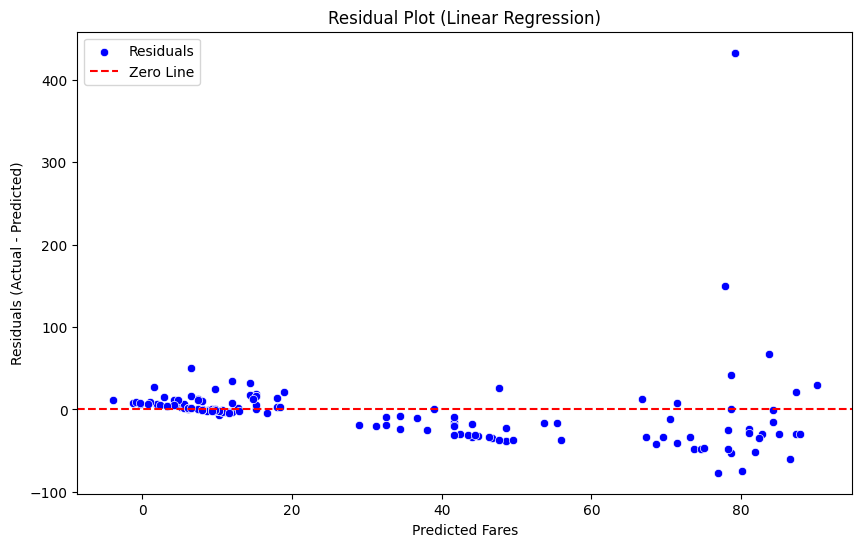

In [5]:
# Additional analysis plot to better understand the Linear Regression model
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate residuals
residuals = y_test_reg - y_pred_reg

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_reg, y=residuals, color='blue', label='Residuals')
plt.axhline(y=0, color='red', linestyle='--', label='Zero Line')
plt.title('Residual Plot (Linear Regression)')
plt.xlabel('Predicted Fares')
plt.ylabel('Residuals (Actual - Predicted)')
plt.legend()
plt.show()

In [6]:
# Actual vs. Predicted Fare comparisson

report_df = pd.DataFrame({
    'Actual Fare': y_test_reg,
    'Predicted Fare': y_pred_reg,
    'Absolute Error': abs(y_test_reg - y_pred_reg)
})

# Show the top 10 biggest misses
print(report_df.sort_values(by='Absolute Error', ascending=False).head(10))

     Actual Fare  Predicted Fare  Absolute Error
258     512.3292       79.157130      433.172070
737     512.3292       79.157130      433.172070
716     227.5250       77.783531      149.741469
263       0.0000       76.867799       76.867799
872       5.0000       80.072862       75.072862
498     151.5500       83.735792       67.814208
136      26.2833       86.482990       60.199690
572      26.3875       78.699264       52.311764
782      30.0000       81.904327       51.904327
169      56.4958        6.531495       49.964305


## Part 3: Logistic Regression
**Concept:** Despite its name, Logistic Regression is a **classification** algorithm. It works by calculating the probability that a given input belongs to a certain class. It's one of the most widely used and interpretable classification models.
*   **Problem:** We will predict whether a passenger `Survived` based on their `Age`, `Pclass`, and `Sex`.

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
# Prepare data for classification
# We need to encode 'Sex' column df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# Define features and target features_cls = ['Age', 'Pclass', 'Sex']target_cls = 'Survived'X_cls = df[features_cls]y_cls = df[target_cls]
features_cls = ['Age', 'Pclass', 'Sex']
target_cls = 'Survived'
x_cls = df[features_cls]
y_cls = df[target_cls]

# Split the data X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)
x_train_cls, x_test_cls, y_train_cls, y_test_cls = train_test_split(x_cls, y_cls, test_size = 0.2, random_state = 42)

### Task 2: Train and Evaluate a Logistic Regression Model
**Your Task:**
1.  Create an instance of the `LogisticRegression` model.
2.  Train the model using the classification training data.
3.  Make predictions on the test data.
4.  Evaluate the model using `accuracy_score`.

In [4]:
# --- ENTER YOUR CODE HERE ---

from sklearn.metrics import classification_report

# 1. Create the model instance
# log_model = ...
log_model = LogisticRegression()

# 2. Train the model
# log_model.fit(...)
log_model.fit(x_train_cls, y_train_cls)

# 3. Make predictions
# y_pred_cls = log_model.predict(...)
y_pred_cls = log_model.predict(x_test_cls)

# 4. Evaluate the model
# accuracy = accuracy_score(y_test_cls, y_pred_cls)
accuracy = accuracy_score(y_test_cls, y_pred_cls)
# print(f"Accuracy for Survival Prediction: {accuracy:.2%}")
print(f"Accuracy for Survival Prediction: {accuracy:.2%}")
print("\nReport:\n", classification_report(y_test_cls, y_pred_cls))

Accuracy for Survival Prediction: 74.83%

Report:
               precision    recall  f1-score   support

           0       0.80      0.78      0.79        87
           1       0.67      0.70      0.68        56

    accuracy                           0.75       143
   macro avg       0.74      0.74      0.74       143
weighted avg       0.75      0.75      0.75       143



## 📝 Knowledge Check
**Instructions:** Answer the following questions in this markdown cell.
1.  **In your own words, what is the key difference between a regression problem and a classification problem?**
2.  **The `LinearRegression` model has an attribute called `.coef_`. After you train the model, print `lr_model.coef_`. What do these numbers represent?**
3.  **Why did we use `mean_squared_error` to evaluate the regression model but `accuracy_score` for the classification model?** Why wouldn't accuracy be a good metric for the fare prediction task?

**[ENTER YOUR ANSWERS HERE]**

1. The key difference between the **regression** and the **classification** problems is the type of data present required to solve the problem. A **regression** problem is to predict values in a continuous pattern, like house prices or future temperatures. Whereas the **classification** problem presents data that needs to be sorted, classified or categorized, like interpreting pixels in an image to recognize a frog from a bird.
2. These coeficents represent the weights or slopes of the features, in this case `Age` and `Class`. They show in which direction and strength of the relationship between each feature and the target variable `Fare`. It represents how much the predicted **Fare** is expected to change if that feature increases by 1 unit, assuming all other features stay the same. This means is for each year older a passenger is, the model predicts their ticket price drops by about `$0.46`. While moving down a ticket class (from 1st to 2nd, or 2nd to 3rd) predicted ticket prices drop by `$37.92`.
3. The **MSE** is used to understand the how far away the calculated/predicted values are from the actual values, in a **regression** model, this works well for models that predict values in a continuous series. The **accuracy score** normalizes all values to fit in between 0 and 1. This evaluation fits best for a classification model as it is required to evaluate the results in a binary context. Hence, the accuracy test would not work well for the fare prediction task due the model predicts continuos values with no limits.